In [5]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import mlflow
import mlflow.sklearn
import pandas as pd
from sklearn.model_selection import train_test_split

from src.data.load_data import load_data

In [6]:
PROJECT_ROOT

WindowsPath('c:/Users/pomia/Projects/customer-intelligence-ml-platform')

In [7]:
mlflow.set_tracking_uri(
    "http://127.0.0.1:5000"
)

mlflow.set_experiment(
    "customer-churn"
)

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1786050839413, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1786050839413, lifecycle_stage='active', name='customer-churn', tags={}, trace_location=None, workspace='default'>

In [8]:
df = load_data()

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
X = df.drop(
    columns=["Churn", "customerID"]
)

y = df["Churn"].map(
    {
        "No": 0,
        "Yes": 1
    }
)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [11]:
from src.evaluation.evaluate import evaluate_model
from src.pipelines.churn_pipeline import create_pipeline

In [12]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
]

categorical_features = [
    col
    for col in X.columns
    if col not in numeric_features
]

In [13]:
clf = create_pipeline(
    model_name="logistic_regression",
    numeric_features=numeric_features,
    categorical_features=categorical_features,
)

In [14]:
with mlflow.start_run(
    run_name="logistic-regression"
):

    clf.fit(
        X_train,
        y_train,
    )

    metrics = evaluate_model(
        clf,
        X_test,
        y_test,
    )

    mlflow.log_param(
        "model",
        "Logistic Regression",
    )

    for name, value in metrics.items():
        mlflow.log_metric(
            name,
            value,
        )

    mlflow.sklearn.log_model(
        clf,
        "model",
        serialization_format="cloudpickle",
    )

    print(metrics)

2026/08/08 11:50:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/08 11:50:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/08 11:50:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


{'accuracy': 0.8055358410220014, 'precision': 0.6572327044025157, 'recall': 0.5588235294117647, 'f1': 0.6040462427745664, 'roc_auc': 0.8418610659019866}
🏃 View run logistic-regression at: http://127.0.0.1:5000/#/experiments/1/runs/ecc7893aa54b48ab8d9ea044505943a5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [15]:
from src.evaluation.evaluate import evaluate_model
from src.pipelines.churn_pipeline import create_pipeline

In [16]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
]

categorical_features = [
    col
    for col in X.columns
    if col not in numeric_features
]

In [17]:
clf = create_pipeline(
    model_name="random_forest",
    numeric_features=numeric_features,
    categorical_features=categorical_features,
)

In [18]:
with mlflow.start_run(
    run_name="random_forest"
):

    clf.fit(
        X_train,
        y_train,
    )

    metrics = evaluate_model(
        clf,
        X_test,
        y_test,
    )

    mlflow.log_param(
        "model",
        "Random Forest",
    )

    for name, value in metrics.items():
        mlflow.log_metric(
            name,
            value,
        )

    mlflow.sklearn.log_model(
        clf,
        "model",
        serialization_format="cloudpickle",
    )

    print(metrics)

2026/08/08 11:56:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/08 11:56:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/08 11:57:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


{'accuracy': 0.7757274662881476, 'precision': 0.6, 'recall': 0.46524064171123, 'f1': 0.5240963855421686, 'roc_auc': 0.8185925753700691}
🏃 View run random_forest at: http://127.0.0.1:5000/#/experiments/1/runs/29931af606584633ad641324a8da0774
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [21]:
X_train.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [22]:
X_train.shape

(5634, 19)

In [23]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65
3151,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55
4860,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35
3867,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70
3810,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55


In [24]:
X_train.columns.tolist()

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges']

In [25]:
y_train.value_counts()

Churn
0    4139
1    1495
Name: count, dtype: int64

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

In [27]:
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns

numeric_features = X_train.select_dtypes(
    exclude=["object"]
).columns

In [28]:
print("Categorical:", list(categorical_features))
print("Numeric:", list(numeric_features))

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

In [30]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

In [31]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ]
)

In [32]:
xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [33]:
y_pred = xgb_pipeline.predict(X_test)
y_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

In [34]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba)
}

metrics

{'accuracy': 0.8048261178140526,
 'precision': 0.6666666666666666,
 'recall': 0.5294117647058824,
 'f1': 0.5901639344262295,
 'roc_auc': 0.8433633005244259}

In [35]:
from sklearn.model_selection import RandomizedSearchCV

In [36]:
param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 7]
}

In [37]:
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [38]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 4, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit

In [39]:
print("Best ROC-AUC:", random_search.best_score_)
print("Best parameters:")
print(random_search.best_params_)

Best ROC-AUC: 0.8490502512517655
Best parameters:
{'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.9}


In [40]:
best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

In [41]:
tuned_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba)
}

tuned_metrics

{'accuracy': 0.8062455642299503,
 'precision': 0.6711864406779661,
 'recall': 0.5294117647058824,
 'f1': 0.5919282511210763,
 'roc_auc': 0.8466700250587718}

In [44]:
import mlflow
import mlflow.sklearn

In [45]:
with mlflow.start_run(run_name="XGBoost Tuned"):

    # Parameters
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("tuned", True)
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 3)
    mlflow.log_param("learning_rate", 0.03)
    mlflow.log_param("min_child_weight", 5)
    mlflow.log_param("subsample", 1.0)
    mlflow.log_param("colsample_bytree", 0.9)

    # Cross-validation score
    mlflow.log_metric(
        "cv_roc_auc",
        random_search.best_score_
    )

    # Test metrics
    for metric_name, metric_value in tuned_metrics.items():
        mlflow.log_metric(metric_name, metric_value)

    # Model
    mlflow.sklearn.log_model(
    best_xgb,
    "model",
    serialization_format="cloudpickle"
)

2026/08/08 12:32:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/08 12:32:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/08 12:32:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run XGBoost Tuned at: http://127.0.0.1:5000/#/experiments/1/runs/43d70571922246fe8c31dea8535e8dd6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [46]:
runs = mlflow.search_runs(
    experiment_names=["customer-churn"]
)

runs[
    [
        "run_id",
        "tags.mlflow.runName",
        "metrics.accuracy",
        "metrics.precision",
        "metrics.recall",
        "metrics.f1",
        "metrics.roc_auc"
    ]
]

,run_id,tags.mlflow.runName,metrics.accuracy,metrics.precision,metrics.recall,metrics.f1,metrics.roc_auc
0,43d70571922246fe8c31dea8535e8dd6,XGBoost Tuned,0.806246,0.671186,0.529412,0.591928,0.846670
1,53697b2a08ee4dff9f45fc645123b234,XGBoost Tuned,0.806246,0.671186,0.529412,0.591928,0.846670
2,29931af606584633ad641324a8da0774,random_forest,0.775727,0.600000,0.465241,0.524096,0.818593
3,ecc7893aa54b48ab8d9ea044505943a5,logistic-regression,0.805536,0.657233,0.558824,0.604046,0.841861
4,8d7351c29841428da3df8318fd957191,logistic-regression-training,0.805536,0.657233,0.558824,0.604046,0.841861
5,1d9195af0aa84562baa9b937a3baac9b,logistic-regression-training,0.805536,0.657233,0.558824,0.604046,0.841861
6,867321e9197a4621977addbcb3422043,logistic-regression-training,NaN,NaN,NaN,NaN,NaN
7,da3edb6c80664b59bfc8b75030fcbe0c,logistic-regression-baseline,NaN,NaN,NaN,0.600828,0.844974
8,ea7e4ab37941480c9b1fd9925b544afd,logistic-regression-baseline,NaN,NaN,NaN,0.600828,0.844974


In [49]:
[x for x in globals() if "model" in x.lower() or "pipeline" in x.lower()]


['create_pipeline', 'evaluate_model', 'xgb_model', 'Pipeline', 'xgb_pipeline']

In [50]:
import inspect

print(inspect.getsource(create_pipeline))

def create_pipeline(
    model_name: str,
    numeric_features: list[str],
    categorical_features: list[str],
) -> Pipeline:
    """
    Create ML pipeline for churn prediction.

    Args:
        model_name: Name of ML model.
        numeric_features: Numeric feature names.
        categorical_features: Categorical feature names.

    Returns:
        sklearn Pipeline.
    """

    preprocessor = create_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
    )

    if model_name == "logistic_regression":
        model = LogisticRegression(
            max_iter=1000,
        )

    elif model_name == "random_forest":
        model = RandomForestClassifier(
            n_estimators=200,
            random_state=42,
        )

    else:
        raise ValueError(
            f"Unknown model: {model_name}"
        )

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,


In [51]:
logistic_pipeline = create_pipeline(
    model_name="logistic_regression",
    numeric_features=numeric_features,
    categorical_features=categorical_features,
)

In [52]:
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [53]:
y_pred_lr = logistic_pipeline.predict(X_test)

In [54]:
y_pred_xgb = best_xgb.predict(X_test)

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

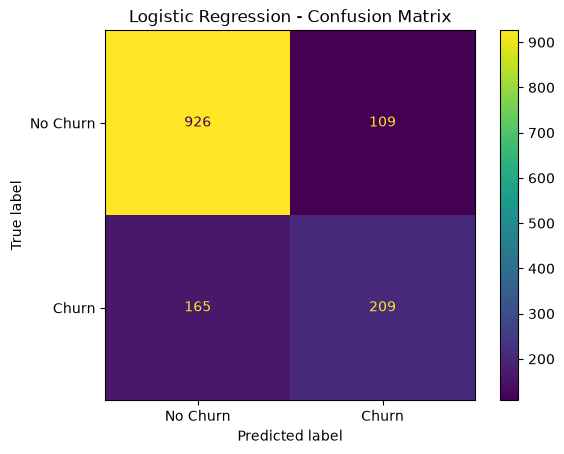

In [56]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

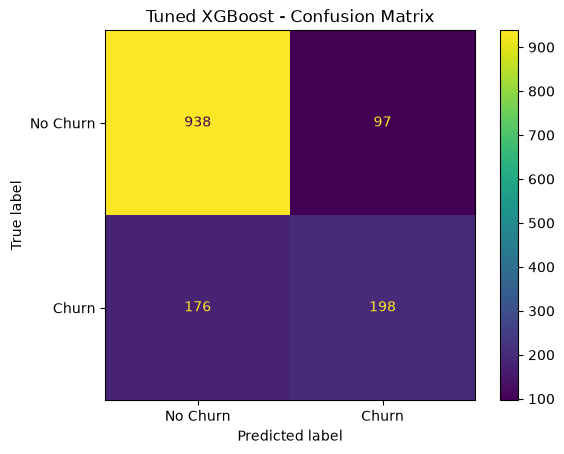

In [57]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Tuned XGBoost - Confusion Matrix")
plt.show()

In [58]:
print("Logistic Regression:")
print(cm_lr)

print("\nTuned XGBoost:")
print(cm_xgb)

Logistic Regression:
[[926 109]
 [165 209]]

Tuned XGBoost:
[[938  97]
 [176 198]]


In [59]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

y_pred_lr = logistic_pipeline.predict(X_test)
y_proba_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

final_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr),
    "recall": recall_score(y_test, y_pred_lr),
    "f1": f1_score(y_test, y_pred_lr),
    "roc_auc": roc_auc_score(y_test, y_proba_lr)
}

final_metrics

{'accuracy': 0.8055358410220014,
 'precision': 0.6572327044025157,
 'recall': 0.5588235294117647,
 'f1': 0.6040462427745664,
 'roc_auc': 0.8418610659019866}

In [60]:
with mlflow.start_run(run_name="Logistic Regression - Champion"):

    # Model information
    mlflow.log_param("model", "Logistic Regression")
    mlflow.log_param("role", "champion")
    
    # Model parameters
    mlflow.log_param("max_iter", 1000)

    # Metrics
    for metric_name, metric_value in final_metrics.items():
        mlflow.log_metric(metric_name, metric_value)

    # Model
    mlflow.sklearn.log_model(
        logistic_pipeline,
        "model",
        serialization_format="cloudpickle"
    )

2026/08/08 12:51:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/08 12:51:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/08 12:51:58 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run Logistic Regression - Champion at: http://127.0.0.1:5000/#/experiments/1/runs/8201327f119d44bdaf23279c8fad9495
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [61]:
run_id = "8201327f119d44bdaf23279c8fad9495"

model_uri = f"runs:/{run_id}/model"

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name="customer-churn-model"
)

print(registered_model)

Successfully registered model 'customer-churn-model'.
2026/08/08 12:55:21 WARNING mlflow.tracking._model_registry.fluent: Run with id 8201327f119d44bdaf23279c8fad9495 has no artifacts at artifact path 'model', registering model based on models:/m-eee17658ab4f47f4af2c84a85808b51b instead
2026/08/08 12:55:21 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: customer-churn-model, version 1


<ModelVersion: aliases=[], creation_timestamp=1786186521576, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1786186521576, metrics=None, model_id=None, name='customer-churn-model', params=None, run_id='8201327f119d44bdaf23279c8fad9495', run_link='', source='models:/m-eee17658ab4f47f4af2c84a85808b51b', status='READY', status_message=None, tags={}, user_id='', version='1', workspace='default'>


Created version '1' of model 'customer-churn-model'.


In [62]:
model = mlflow.sklearn.load_model(
    "models:/customer-churn-model/1"
)

In [63]:
predictions = model.predict(X_test)

predictions[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0])

In [64]:
probabilities = model.predict_proba(X_test)[:, 1]

probabilities[:10]

array([0.04529387, 0.68441126, 0.05872074, 0.40170424, 0.02154772,
       0.60393536, 0.44922498, 0.13005522, 0.00288077, 0.39517899])